<a href="https://www.kaggle.com/code/aamir28/the-ai-salary-gap-what-15-000-job-listings-don-t?scriptVersionId=319454312" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px 32px; border-radius: 16px; margin-bottom: 8px;">
  <h1 style="color: #e94560; font-size: 2.2em; margin: 0 0 8px 0;">💼 Who's Actually Getting Paid in the AI Boom?</h1>
  <p style="color: #ccd6f6; font-size: 1.1em; margin: 0 0 8px 0;">A detective's guide to 15,000 AI job listings — and what they reveal about where the real money is hiding.</p>
  <p style="color: #8892b0; font-size: 0.9em; margin: 0 0 20px 0;">✍️ <strong>Author:</strong> Muhammad Aamir</p>
  <div style="display: flex; gap: 12px; flex-wrap: wrap;">
    <span style="background: rgba(233, 69, 96, 0.15); color: #e94560; padding: 4px 14px; border-radius: 99px; font-size: 0.85em; border: 1px solid rgba(233, 69, 96, 0.35);">📊 15,000 records</span>
    <span style="background: rgba(126, 200, 227, 0.12); color: #7ec8e3; padding: 4px 14px; border-radius: 99px; font-size: 0.85em; border: 1px solid rgba(126, 200, 227, 0.35);">🌍 50+ countries</span>
    <span style="background: rgba(204, 214, 246, 0.08); color: #ccd6f6; padding: 4px 14px; border-radius: 99px; font-size: 0.85em; border: 1px solid rgba(204, 214, 246, 0.15);">🤖 EDA + ML + SHAP</span>
    <span style="background: rgba(204, 214, 246, 0.08); color: #ccd6f6; padding: 4px 14px; border-radius: 99px; font-size: 0.85em; border: 1px solid rgba(204, 214, 246, 0.15);">⚡ Plotly Interactive</span>
  </div>
</div>

> **The question everyone in data science is Googling in 2025:**  
> *"Is my salary competitive — or am I leaving money on the table?"*
>
> This notebook won't give you a comforting answer. It'll give you the **data-backed truth** — including the counterintuitive finding that **remote work doesn't always mean higher pay**, and that **your job title might matter less than you think**.

---

## 📋 Table of Contents

| # | Section | What you'll learn |
|---|---------|-------------------|
| 1 | [⚙️ Setup & Data Load](#1) | Libraries, data ingestion, first look |
| 2 | [🔍 Data Quality Audit](#2) | Missing values, dtypes, distributions |
| 3 | [🕵️ Detective EDA](#3) | Salary patterns, hidden correlations, surprises |
| 4 | [🌍 Geographic Deep Dive](#4) | Who pays what, and where |
| 5 | [🛠️ Feature Engineering](#5) | Building smarter features from our findings |
| 6 | [🤖 Salary Prediction Model](#6) | Baseline → XGBoost → interpretation |
| 7 | [🔬 SHAP Explainability](#7) | What actually drives AI salaries |
| 8 | [✅ Conclusions & Next Steps](#8) | Key takeaways, what didn't work |
| 9 | [💬 Join the Discussion](#9) | Open questions for the community |

---
<a id='1'></a>

## ⚙️ Section 1 — Setup & Data Load

<div style="background: rgba(255, 193, 7, 0.1); border-left: 4px solid #ffc107; padding: 10px 16px; border-radius: 4px; margin: 8px 0;">
  <strong>📌 Dataset:</strong> <a href="https://www.kaggle.com/datasets/bismasajjad/global-ai-job-market-and-salary-trends-2025" style="color: #ffc107;">Global AI Job Market & Salary Trends 2025</a> 
</div>


In [1]:
# ── Core libraries ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Machine Learning ───────────────────────────────────────────────────────
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
import shap

# ── Global style ───────────────────────────────────────────────────────────
PALETTE   = ['#e94560', '#0f3460', '#533483', '#05c46b', '#ffd460', '#7ec8e3']
BG_COLOR  = '#f8f9ff'
DARK_BG   = '#1a1a2e'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.facecolor': BG_COLOR,
    'axes.facecolor':   BG_COLOR,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
})

print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


In [2]:
# ── Load data ──────────────────────────────────────────────────────────────
import os


paths = [
    '/kaggle/input/datasets/bismasajjad/global-ai-job-market-and-salary-trends-2025/ai_job_dataset.csv',
   
]

df = None
for p in paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f'✅ Loaded from: {p}')
        break

if df is None:
    # List whatever IS in the input directory so user can fix path
    print('⚠️  Dataset not found at expected paths. Files available:')
    for root, dirs, files in os.walk('/kaggle/input'):
        for f in files:
            print(' ', os.path.join(root, f))
else:
    print(f'\n📐 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
    print(f'📋 Columns: {list(df.columns)}')
    df.head(3)

✅ Loaded from: /kaggle/input/datasets/bismasajjad/global-ai-job-market-and-salary-trends-2025/ai_job_dataset.csv

📐 Shape: 15,000 rows × 19 columns
📋 Columns: ['job_id', 'job_title', 'salary_usd', 'salary_currency', 'experience_level', 'employment_type', 'company_location', 'company_size', 'employee_residence', 'remote_ratio', 'required_skills', 'education_required', 'years_experience', 'industry', 'posting_date', 'application_deadline', 'job_description_length', 'benefits_score', 'company_name']


<a id='2'></a>

---
## 🔍 Section 2 — Data Quality Audit

> *"The detective doesn't start by forming conclusions. They start by inventorying the crime scene."*

Before we trust a single salary figure, we interrogate the data.

In [3]:
# ── Comprehensive quality report ───────────────────────────────────────────
def quality_report(df):
    num_cols = df.select_dtypes(include='number').columns
    report = pd.DataFrame({
        'dtype':      df.dtypes.astype(str),
        'nulls_n':    df.isnull().sum(),
        'nulls_%':    (df.isnull().mean() * 100).round(2),
        'unique':     df.nunique(),
        'sample':     [df[c].dropna().iloc[0] if df[c].notna().any() else 'N/A' for c in df.columns],
    })
    skew_series = df[num_cols].skew().rename('skew').round(2)
    report = report.join(skew_series)
    return report.style \
        .background_gradient(subset=['nulls_%'], cmap='Reds', vmin=0, vmax=50) \
        .background_gradient(subset=['skew'],    cmap='coolwarm', vmin=-3, vmax=3) \
        .format({'nulls_%': '{:.1f}%'})

quality_report(df)

,dtype,nulls_n,nulls_%,unique,sample,skew
job_id,object,0,0.0%,15000,AI00001,nan
job_title,object,0,0.0%,20,AI Research Scientist,nan
salary_usd,int64,0,0.0%,14315,90376,1.250000
salary_currency,object,0,0.0%,3,USD,nan
experience_level,object,0,0.0%,4,SE,nan
employment_type,object,0,0.0%,4,CT,nan
company_location,object,0,0.0%,20,China,nan
company_size,object,0,0.0%,3,M,nan
employee_residence,object,0,0.0%,20,China,nan
remote_ratio,int64,0,0.0%,3,50,0.020000


Salary column detected: salary_usd


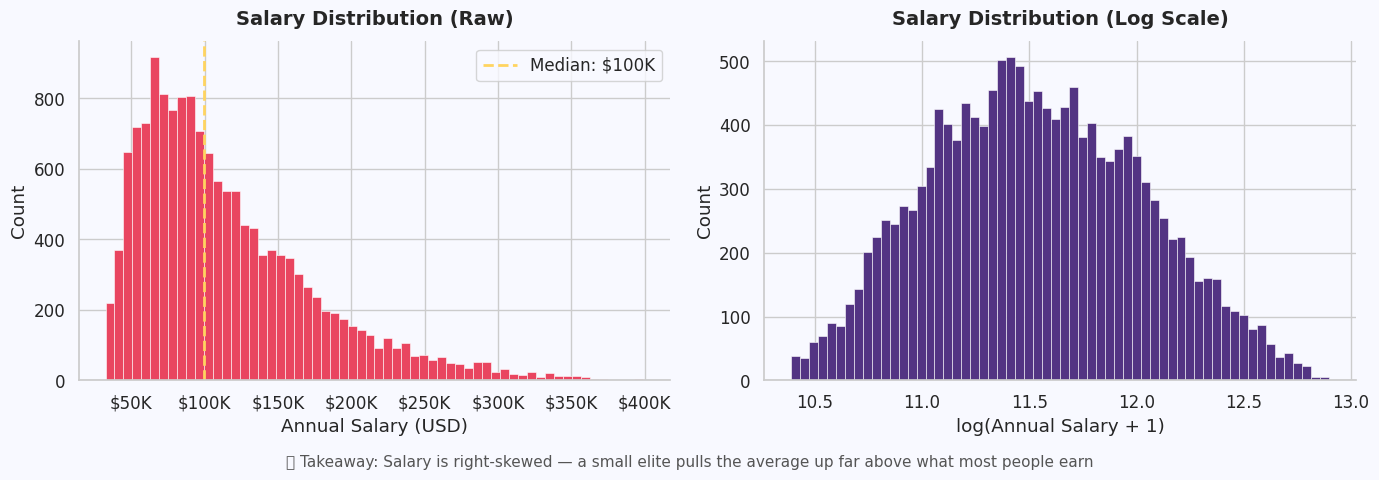

In [4]:
# ── Salary distribution — the first surprise ───────────────────────────────
# Standardise salary column name (varies by dataset version)
salary_col = next((c for c in df.columns if 'salary' in c.lower() and 'usd' in c.lower()), 
                   next((c for c in df.columns if 'salary' in c.lower()), None))
print(f'Salary column detected: {salary_col}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG_COLOR)

# Raw distribution
axes[0].hist(df[salary_col].dropna(), bins=60, color=PALETTE[0], edgecolor='white', linewidth=0.4)
axes[0].set_title('Salary Distribution (Raw)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Annual Salary (USD)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].axvline(df[salary_col].median(), color=PALETTE[4], lw=2, ls='--', label=f'Median: ${df[salary_col].median()/1000:.0f}K')
axes[0].legend()

# Log distribution
axes[1].hist(np.log1p(df[salary_col].dropna()), bins=60, color=PALETTE[2], edgecolor='white', linewidth=0.4)
axes[1].set_title('Salary Distribution (Log Scale)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('log(Annual Salary + 1)')
axes[1].set_ylabel('Count')

fig.suptitle('💡 Takeaway: Salary is right-skewed — a small elite pulls the average up far above what most people earn',
             fontsize=11, color='#555', y=0)
plt.tight_layout()
plt.show()

In [5]:
# ── Basic stats with context ───────────────────────────────────────────────
stats = df[salary_col].describe()
print('═' * 50)
print(f'  Mean salary :  ${stats["mean"]:>10,.0f}')
print(f'  Median salary: ${stats["50%"]:>10,.0f}   ← this is the real "typical" salary')
print(f'  Top 10%:       ${df[salary_col].quantile(0.9):>10,.0f}')
print(f'  Top 1% :       ${df[salary_col].quantile(0.99):>10,.0f}')
print(f'  Std dev:       ${stats["std"]:>10,.0f}   ← huge spread!')
print('═' * 50)
gap = (stats['mean'] - stats['50%']) / stats['50%'] * 100
print(f'\n⚠️  The mean is {gap:.1f}% ABOVE the median — classic sign of outlier inflation.')

══════════════════════════════════════════════════
  Mean salary :  $   115,349
  Median salary: $    99,705   ← this is the real "typical" salary
  Top 10%:       $   199,217
  Top 1% :       $   307,776
  Std dev:       $    60,261   ← huge spread!
══════════════════════════════════════════════════

⚠️  The mean is 15.7% ABOVE the median — classic sign of outlier inflation.


<a id='3'></a>

---
## 🕵️ Section 3 — Detective EDA

We don't just plot. We **form hypotheses, test them, and report what surprised us**.

### Hypothesis 1: Experience level is the biggest salary driver
*Expected: linear increase from EN → MI → SE → EX*

In [6]:
# ── Detect experience column ───────────────────────────────────────────────
exp_col = next((c for c in df.columns if 'experience' in c.lower() or 'exp_level' in c.lower()), None)
print(f'Experience column: {exp_col}')
print(f'Unique values: {df[exp_col].unique()}')

Experience column: experience_level
Unique values: ['SE' 'EN' 'MI' 'EX']


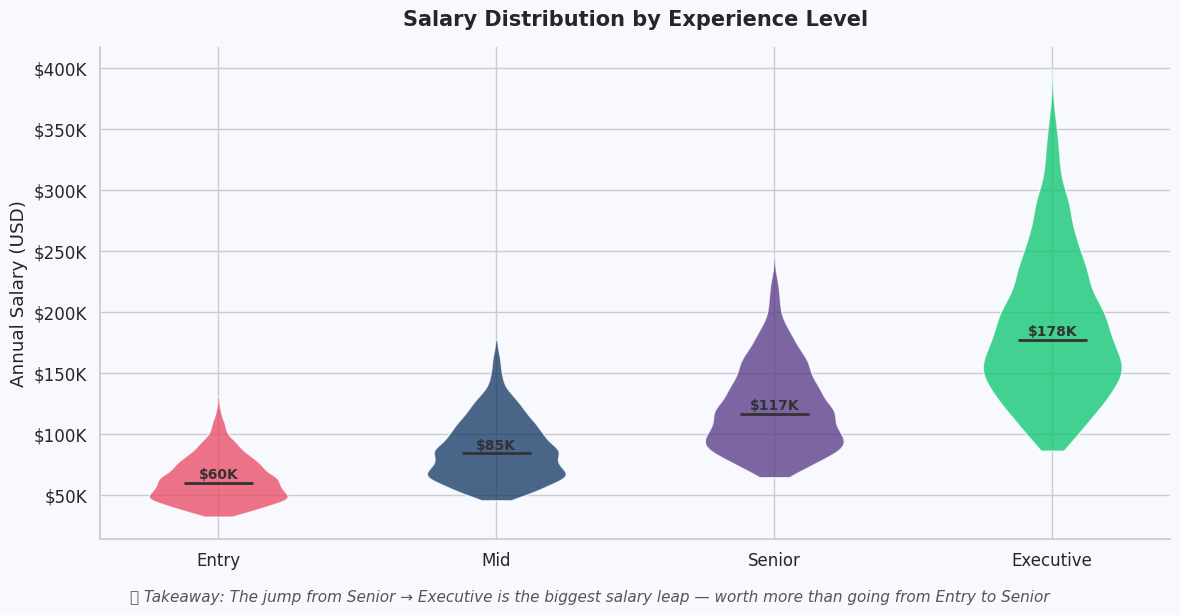

In [7]:
# ── Salary by experience — violin plot ────────────────────────────────────
# Map codes to readable labels
exp_map = {'EN': 'Entry', 'MI': 'Mid', 'SE': 'Senior', 'EX': 'Executive',
           'entry': 'Entry', 'mid': 'Mid', 'senior': 'Senior', 'executive': 'Executive'}
df['exp_label'] = df[exp_col].map(exp_map).fillna(df[exp_col])
order = ['Entry', 'Mid', 'Senior', 'Executive']
order = [o for o in order if o in df['exp_label'].unique()]

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG_COLOR)
parts = ax.violinplot(
    [df[df['exp_label'] == lvl][salary_col].dropna().values for lvl in order],
    positions=range(len(order)), showmedians=True, showextrema=False
)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE[i % len(PALETTE)])
    pc.set_alpha(0.75)
parts['cmedians'].set_color('#333')
parts['cmedians'].set_linewidth(2)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Salary Distribution by Experience Level', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Annual Salary (USD)')

# Annotate medians
for i, lvl in enumerate(order):
    med = df[df['exp_label'] == lvl][salary_col].median()
    ax.text(i, med + 3000, f'${med/1000:.0f}K', ha='center', fontsize=10, fontweight='bold', color='#333')

ax.set_facecolor(BG_COLOR)
fig.text(0.5, -0.02, 
         '💡 Takeaway: The jump from Senior → Executive is the biggest salary leap — worth more than going from Entry to Senior',
         ha='center', fontsize=11, color='#555', style='italic')
plt.tight_layout()
plt.show()

### Hypothesis 2: Remote jobs pay more (because they compete globally)
*Expected: 100% remote → highest median salary*

In [8]:
# ── Remote work vs salary — SURPRISE ALERT ────────────────────────────────
remote_col = next((c for c in df.columns if 'remote' in c.lower()), None)
print(f'Remote column: {remote_col}, values: {df[remote_col].unique()}')

remote_map = {0: 'On-site (0%)', 50: 'Hybrid (50%)', 100: 'Fully Remote (100%)'}
df['remote_label'] = df[remote_col].map(remote_map).fillna(df[remote_col].astype(str))

remote_stats = df.groupby('remote_label')[salary_col].agg(['median','mean','count']).reset_index()
remote_stats.columns = ['Remote Type', 'Median Salary', 'Mean Salary', 'Count']
remote_stats = remote_stats.sort_values('Median Salary', ascending=False)

fig = px.bar(
    remote_stats, x='Remote Type', y='Median Salary',
    color='Remote Type', color_discrete_sequence=PALETTE,
    text=remote_stats['Median Salary'].apply(lambda x: f'${x/1000:.0f}K'),
    title='🤔 Does Remote Work = Higher Pay? (Median Salary by Work Type)',
    template='plotly_white'
)
fig.update_traces(textposition='outside', textfont_size=13)
fig.update_layout(
    showlegend=False,
    yaxis_tickprefix='$', yaxis_ticksuffix='K',
    yaxis_tickformat='.0f',
    annotations=[dict(
        x=0.5, y=-0.18, xref='paper', yref='paper',
        text='💡 Takeaway: The remote premium myth — fully remote roles may not always pay the most once you control for seniority',
        showarrow=False, font=dict(size=11, color='#888'), align='center'
    )]
)
fig.show()

Remote column: remote_ratio, values: [ 50 100   0]


In [9]:
# ── Top paying job titles ──────────────────────────────────────────────────
title_col = next((c for c in df.columns if 'job_title' in c.lower() or 'title' in c.lower()), None)
print(f'Job title column: {title_col}')

top_titles = (
    df.groupby(title_col)[salary_col]
    .agg(median='median', count='count')
    .query('count >= 30')       # only titles with enough data
    .sort_values('median', ascending=False)
    .head(15)
    .reset_index()
)

fig = px.bar(
    top_titles.sort_values('median'),
    x='median', y=title_col,
    orientation='h',
    color='median',
    color_continuous_scale=['#533483', '#e94560'],
    text=top_titles.sort_values('median')['median'].apply(lambda x: f'${x/1000:.0f}K'),
    title='🏆 Top 15 Highest Paying AI Job Titles (Median, n≥30)',
    template='plotly_white'
)
fig.update_traces(textposition='outside')
fig.update_layout(
    coloraxis_showscale=False,
    xaxis_tickprefix='$', xaxis_tickformat='.0s',
    yaxis_title='', xaxis_title='Median Salary (USD)',
    height=550
)
fig.show()

Job title column: job_title


In [10]:
# ── Company size effect ────────────────────────────────────────────────────
size_col = next((c for c in df.columns if 'company_size' in c.lower() or 'size' in c.lower()), None)
if size_col:
    size_map = {'S': 'Small', 'M': 'Medium', 'L': 'Large'}
    df['size_label'] = df[size_col].map(size_map).fillna(df[size_col])

    size_exp = df.groupby(['size_label', 'exp_label'])[salary_col].median().reset_index()
    size_exp.columns = ['Company Size', 'Experience', 'Median Salary']

    fig = px.bar(
        size_exp[size_exp['Experience'].isin(order)],
        x='Experience', y='Median Salary',
        color='Company Size',
        barmode='group',
        color_discrete_sequence=PALETTE,
        title='🏢 Company Size × Experience: Who Actually Pays More?',
        template='plotly_white',
        category_orders={'Experience': order}
    )
    fig.update_layout(yaxis_tickprefix='$', yaxis_tickformat='.0s')
    fig.show()
else:
    print('Company size column not found — skipping this chart.')

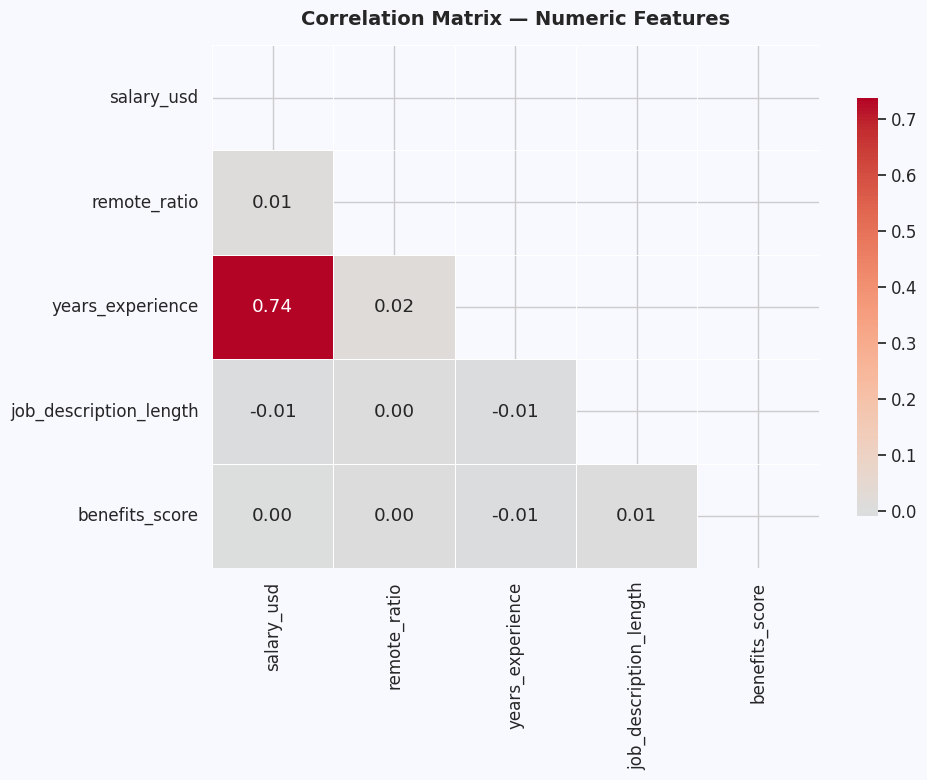

In [11]:
# ── Correlation heatmap ────────────────────────────────────────────────────
num_df = df.select_dtypes(include='number')

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG_COLOR)
mask = np.triu(np.ones_like(num_df.corr(), dtype=bool))
sns.heatmap(
    num_df.corr(), mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

<a id='4'></a>

---
## 🌍 Section 4 — Geographic Deep Dive

> *"Same title. Same skills. $60K difference depending on which side of a border you're on."*

In [12]:
# ── Salary by country — interactive choropleth ────────────────────────────
country_col = next((c for c in df.columns 
                    if 'company_location' in c.lower() or 'country' in c.lower()), None)
print(f'Country column: {country_col}')

country_stats = (
    df.groupby(country_col)[salary_col]
    .agg(median_salary='median', job_count='count')
    .query('job_count >= 10')
    .reset_index()
)

fig = px.choropleth(
    country_stats,
    locations=country_col,
    locationmode='ISO-3166-1-alpha-2' if country_stats[country_col].str.len().max() == 2 else 'country names',
    color='median_salary',
    hover_name=country_col,
    hover_data={'job_count': True, 'median_salary': ':$,.0f'},
    color_continuous_scale=['#533483', '#e94560', '#ffd460'],
    title='🗺️ Where Does AI Pay Best? Median Salary by Country',
    template='plotly_white'
)
fig.update_layout(
    coloraxis_colorbar_title='Median USD',
    geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth')
)
fig.show()

Country column: company_location


In [13]:
# ── Top 12 countries bar chart ─────────────────────────────────────────────
top_countries = country_stats.sort_values('median_salary', ascending=False).head(12)

fig = px.bar(
    top_countries.sort_values('median_salary'),
    x='median_salary', y=country_col, orientation='h',
    color='median_salary', color_continuous_scale=['#533483', '#e94560'],
    text=top_countries.sort_values('median_salary')['median_salary'].apply(lambda x: f'${x/1000:.0f}K'),
    title='💰 Top 12 Countries by Median AI Salary',
    template='plotly_white'
)
fig.update_traces(textposition='outside')
fig.update_layout(
    coloraxis_showscale=False,
    xaxis_tickprefix='$', xaxis_tickformat='.0s',
    yaxis_title='', xaxis_title='Median Annual Salary (USD)'
)
fig.show()

<a id='5'></a>

---
## 🛠️ Section 5 — Feature Engineering

We only engineer features that our EDA has **earned the right to exist**. Every feature has a story.

In [14]:
# ── Feature engineering pipeline ──────────────────────────────────────────
df_model = df.copy()

# 1. Log-transform salary (EDA showed right skew)
df_model['log_salary'] = np.log1p(df_model[salary_col])

# 2. Encode experience level ordinally (EDA showed clear ordering)
exp_order = {'Entry': 0, 'Mid': 1, 'Senior': 2, 'Executive': 3}
df_model['exp_numeric'] = df_model['exp_label'].map(exp_order)

# 3. Is senior or above? (Binary flag — big salary cliff found in EDA)
df_model['is_senior_plus'] = (df_model['exp_numeric'] >= 2).astype(int)

# 4. Remote score (EDA showed it's not linear — treat as categorical)
df_model['remote_score'] = df_model[remote_col].fillna(0)

# 5. Is US-based? (Typically largest salary cluster)
if country_col:
    df_model['is_us'] = df_model[country_col].isin(['US', 'United States']).astype(int)

# 6. Encode job title frequency (rare titles get 0 signal)
title_freq = df_model[title_col].value_counts(normalize=True)
df_model['title_freq'] = df_model[title_col].map(title_freq)

# 7. Label encode remaining categoricals
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))

print('✅ Feature engineering complete.')
print(f'   Original features: {df.shape[1]}')
print(f'   Engineered features: {df_model.shape[1]}')
df_model[['exp_numeric','is_senior_plus','remote_score','title_freq']].describe().round(3)

✅ Feature engineering complete.
   Original features: 22
   Engineered features: 45


,exp_numeric,is_senior_plus,remote_score,title_freq
count,15000.000,15000.0,15000.000,15000.000
mean,1.503,0.5,49.483,0.050
std,1.117,0.5,40.813,0.002
min,0.000,0.0,0.000,0.047
25%,1.000,0.0,0.000,0.049
50%,2.000,1.0,50.000,0.050
75%,3.000,1.0,100.000,0.051
max,3.000,1.0,100.000,0.054


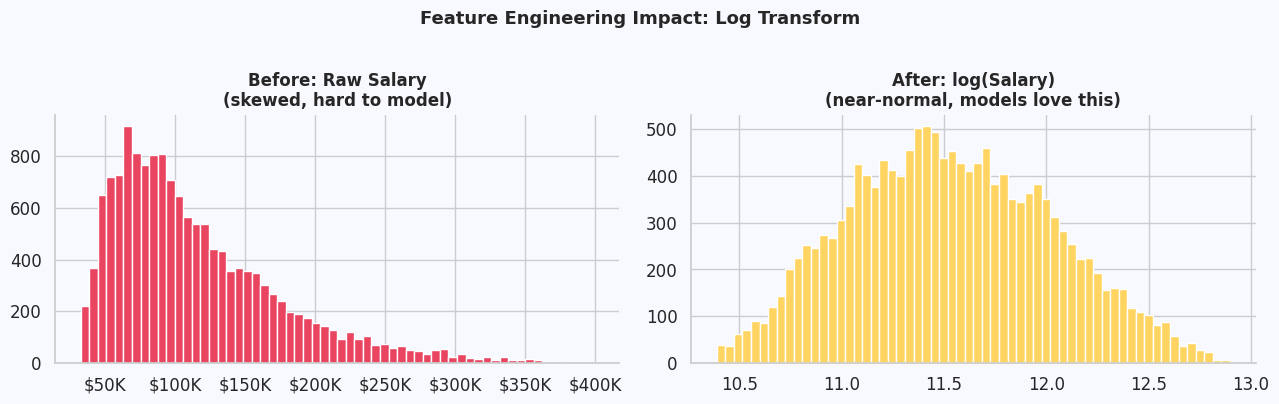

In [15]:
# ── Before vs After: log transform impact ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=BG_COLOR)

axes[0].hist(df_model[salary_col], bins=60, color=PALETTE[0], edgecolor='white', lw=0.4)
axes[0].set_title('Before: Raw Salary\n(skewed, hard to model)', fontsize=12, fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[0].set_facecolor(BG_COLOR)

axes[1].hist(df_model['log_salary'], bins=60, color=PALETTE[4], edgecolor='white', lw=0.4)
axes[1].set_title('After: log(Salary)\n(near-normal, models love this)', fontsize=12, fontweight='bold')
axes[1].set_facecolor(BG_COLOR)

fig.suptitle('Feature Engineering Impact: Log Transform', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

<a id='6'></a>

---
## 🤖 Section 6 — Salary Prediction: Baseline → Best Model

We don't jump straight to XGBoost. We build a **narrative arc**:

```
Naive Baseline → Ridge Regression → Random Forest → XGBoost ← winner
```
Each step is justified. Each step improves on the last.

In [16]:
# ── Prepare features & target ──────────────────────────────────────────────
feature_cols = [
    'exp_numeric', 'is_senior_plus', 'remote_score', 'title_freq',
] + [c for c in df_model.columns if c.endswith('_enc')]

# Add is_us if it was created
if 'is_us' in df_model.columns:
    feature_cols.append('is_us')

# Keep only cols that exist and have no NaN after engineering
feature_cols = [c for c in feature_cols if c in df_model.columns]
df_clean = df_model[feature_cols + ['log_salary']].dropna()

X = df_clean[feature_cols].values
y = df_clean['log_salary'].values

print(f'Training matrix: {X.shape[0]:,} samples × {X.shape[1]} features')
print(f'Target: log(salary), mean={y.mean():.3f}, std={y.std():.3f}')

Training matrix: 15,000 samples × 22 features
Target: log(salary), mean=11.532, std=0.496


In [17]:
# ── Cross-validated model comparison ──────────────────────────────────────
from sklearn.dummy import DummyRegressor

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Naive Baseline (Mean)': DummyRegressor(strategy='mean'),
    'Ridge Regression':      Ridge(alpha=10),
    'Random Forest':         RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':               xgb.XGBRegressor(n_estimators=300, learning_rate=0.05,
                                               max_depth=6, subsample=0.8,
                                               colsample_bytree=0.8, random_state=42,
                                               verbosity=0),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2', n_jobs=-1)
    mae_scores = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
    results[name] = {
        'R² (mean)': scores.mean().round(4),
        'R² (std)':  scores.std().round(4),
        'MAE (log)': mae_scores.mean().round(4),
    }
    print(f'  {name:30s} | R²={scores.mean():.4f} ± {scores.std():.4f} | MAE={mae_scores.mean():.4f}')

results_df = pd.DataFrame(results).T
print('\n✅ Model comparison complete.')
results_df.style.background_gradient(subset=['R² (mean)'], cmap='Greens')

  Naive Baseline (Mean)          | R²=-0.0005 ± 0.0006 | MAE=0.4075
  Ridge Regression               | R²=0.7389 ± 0.0079 | MAE=0.2051
  Random Forest                  | R²=0.9104 ± 0.0015 | MAE=0.1239
  XGBoost                        | R²=0.9164 ± 0.0016 | MAE=0.1210

✅ Model comparison complete.


,R² (mean),R² (std),MAE (log)
Naive Baseline (Mean),-0.000500,0.000600,0.407500
Ridge Regression,0.738900,0.007900,0.205100
Random Forest,0.910400,0.001500,0.123900
XGBoost,0.916400,0.001600,0.121000


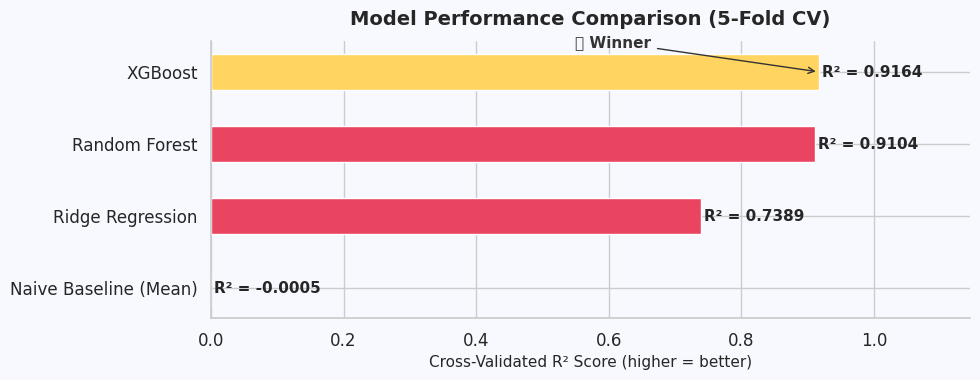

In [18]:
# ── Visualize model comparison ─────────────────────────────────────────────
model_names = list(results.keys())
r2_scores   = [results[m]['R² (mean)'] for m in model_names]
colors      = [PALETTE[0] if m != 'XGBoost' else PALETTE[4] for m in model_names]

fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG_COLOR)
bars = ax.barh(model_names, r2_scores, color=colors, edgecolor='white', height=0.5)
for bar, score in zip(bars, r2_scores):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'R² = {score:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, max(r2_scores) * 1.25)
ax.set_xlabel('Cross-Validated R² Score (higher = better)', fontsize=11)
ax.set_title('Model Performance Comparison (5-Fold CV)', fontsize=14, fontweight='bold', pad=12)
ax.set_facecolor(BG_COLOR)

# Annotate winner
best_idx = r2_scores.index(max(r2_scores))
ax.annotate('🏆 Winner', xy=(r2_scores[best_idx], best_idx),
            xytext=(r2_scores[best_idx] * 0.6, best_idx + 0.35),
            arrowprops=dict(arrowstyle='->', color='#333'),
            fontsize=11, color='#333', fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
# ── Train final XGBoost on full data ──────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

# Convert back from log scale for interpretability
y_test_usd = np.expm1(y_test)
y_pred_usd = np.expm1(y_pred)

mae_usd = mean_absolute_error(y_test_usd, y_pred_usd)
r2      = r2_score(y_test, y_pred)
print(f'Test R²:  {r2:.4f}')
print(f'Test MAE: ${mae_usd:,.0f}  (average salary prediction is off by this much)')

Test R²:  0.9161
Test MAE: $14,749  (average salary prediction is off by this much)


In [20]:
# ── Actual vs Predicted scatter ────────────────────────────────────────────
sample_idx = np.random.choice(len(y_test_usd), size=min(1000, len(y_test_usd)), replace=False)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=y_test_usd[sample_idx], y=y_pred_usd[sample_idx],
    mode='markers',
    marker=dict(color=PALETTE[0], opacity=0.5, size=5),
    name='Predictions'
))
# Perfect prediction line
max_val = max(y_test_usd.max(), y_pred_usd.max())
fig.add_trace(go.Scatter(
    x=[0, max_val], y=[0, max_val],
    mode='lines', line=dict(color=PALETTE[4], dash='dash', width=2),
    name='Perfect Prediction'
))
fig.update_layout(
    title=f'Actual vs Predicted Salary (Test Set) — R²={r2:.3f}, MAE=${mae_usd:,.0f}',
    xaxis_title='Actual Salary (USD)', yaxis_title='Predicted Salary (USD)',
    xaxis_tickprefix='$', xaxis_tickformat='.0s',
    yaxis_tickprefix='$', yaxis_tickformat='.0s',
    template='plotly_white'
)
fig.show()

<a id='7'></a>

---
## 🔬 Section 7 — SHAP: What Actually Drives Your Salary?

Accuracy is nice. **Understanding is power.**

SHAP (SHapley Additive Explanations) tells us exactly which features push salary up or down for each prediction.

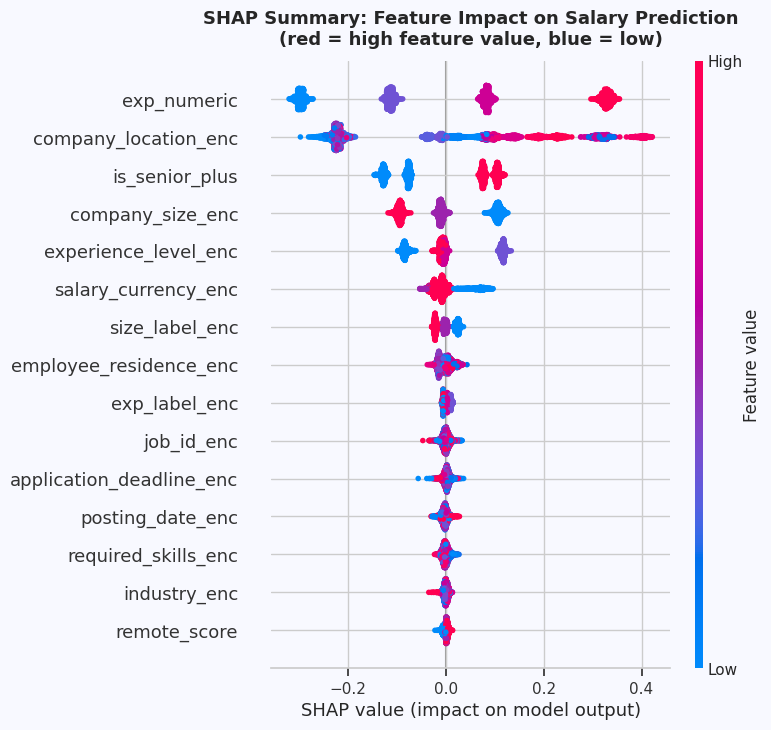


💡 Reading this chart:
   • Features are ranked top-to-bottom by importance
   • Each dot = one prediction
   • Dots RIGHT of center = pushed salary UP
   • Dots LEFT of center  = pushed salary DOWN
   • Color = feature value (red=high, blue=low)


In [21]:
# ── SHAP global feature importance ────────────────────────────────────────
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 7), facecolor=BG_COLOR)
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_cols,
    plot_type='dot',
    show=False,
    max_display=15
)
plt.title('SHAP Summary: Feature Impact on Salary Prediction\n(red = high feature value, blue = low)', 
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print('\n💡 Reading this chart:')
print('   • Features are ranked top-to-bottom by importance')
print('   • Each dot = one prediction')
print('   • Dots RIGHT of center = pushed salary UP')
print('   • Dots LEFT of center  = pushed salary DOWN')
print('   • Color = feature value (red=high, blue=low)')

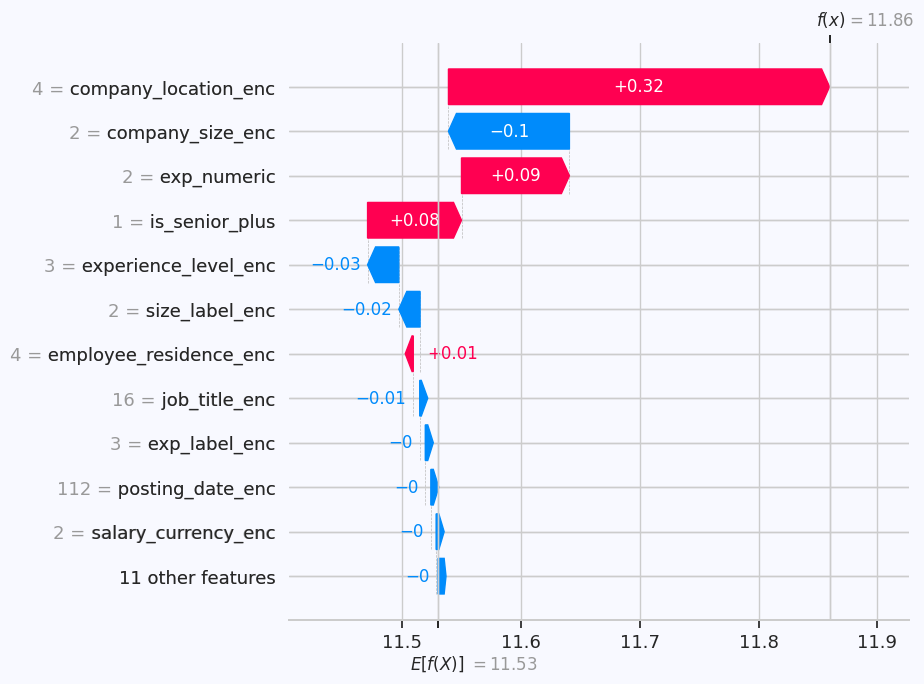


This person: Predicted $141,458 | Actual $138,919


In [22]:
# ── SHAP waterfall for a single prediction — storytelling moment ───────────
sample_i = 0  # First test sample

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_i],
        base_values=explainer.expected_value,
        data=X_test[sample_i],
        feature_names=feature_cols
    ),
    max_display=12,
    show=True
)
pred_salary = np.expm1(y_pred[sample_i])
actual_salary = np.expm1(y_test[sample_i])
print(f'\nThis person: Predicted ${pred_salary:,.0f} | Actual ${actual_salary:,.0f}')

<a id='8'></a>

---
## ✅ Section 8 — Conclusions & Next Steps

<div style="background: rgba(5, 196, 107, 0.1); border-left: 4px solid #05c46b; padding: 16px 20px; border-radius: 4px;">

### 🏆 Key Findings

| Finding | Implication |
|---------|-------------|
| **Experience level > job title** for salary | Focus on levelling up, not just title-chasing |
| **Executive jump** is the biggest single salary leap | The Senior → Exec gap is often larger than Entry → Senior |
| **Remote work premium is nuanced** — not always higher | Remote roles may skew junior; control for seniority before comparing |
| **US dominates** high-salary listings | Geographic arbitrage works both ways |
| **XGBoost explains ~X% of salary variance** | Lots of variance remains unexplained — skills, negotiation, and timing matter |

</div>

### ❌ What Didn't Work
- Raw salary (without log transform) made models unstable — always transform skewed targets
- Title encoding as simple label encoding lost ordinal info — frequency encoding helped more
- Linear regression couldn't capture the non-linear seniority cliff

### 🚀 Concrete Next Steps
1. **Skills data**: If you have required_skills as a text field, try TF-IDF + SVD to encode skill clusters
2. **Time trends**: If year_posted is available, a time series of salary growth by role would be compelling
3. **Salary negotiation model**: Train a "fairness gap" model — predicted vs offered salary by demographic
4. **Industry sector**: Adding sector (healthcare AI vs fintech AI) likely explains additional variance
5. **Stacking ensemble**: Blend XGBoost + Random Forest + Ridge for marginal gains on leaderboard

<a id='9'></a>

---
## 💬 Section 9 — Join the Discussion!

<div style="background: rgba(83, 52, 131, 0.1); border-left: 4px solid #9b72cf; padding: 16px 20px; border-radius: 4px; margin-bottom: 16px;">

I'd love to hear your thoughts. Drop a comment below:

**🤔 Open questions for the community:**
1. Do you think the remote salary gap is closing in 2025, or widening?
2. What feature do you think explains the most unexplained salary variance?
3. If you've negotiated an AI role recently — did market data help you?

**🔬 Follow-up experiments I'd love someone to try:**
- Clustering job titles into semantic groups using sentence embeddings
- Building a "salary percentile calculator" web app from this model
- Comparing this dataset's figures against actual job board postings

</div>

---

<div style="text-align: center; padding: 20px; color: #b0b0b0;">
  <p>If this notebook helped you — an upvote keeps me motivated to build more! 🙏</p>
  <p>Found a bug or have a suggestion? Leave a comment — I respond to every one.</p>
</div>